# Phase 2: Advanced Regime Detection Validation

Validates four advanced regime detection methods:
1. **R²-RD**: Rolling R² structural break detection
2. **RegimeFolio**: VIX term structure-based
3. **Macro**: Macroeconomic indicator-based
4. **Path Signatures**: Rough path signature clustering

## Objectives
1. Run all Phase 2 detectors on SPY 2015-2024 data
2. Compare regime characteristics and persistence
3. Economic significance: Do regimes predict future returns/volatility?
4. Timing analysis: Which detector leads/lags during transitions?
5. Ensemble: Majority vote across all detectors

## Setup & Configuration

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

In [2]:
CONFIG = {
    "data": {
        "ticker": "SPY",
        "start": "2015-01-01",
        "end": "2024-12-31",
    },
    "r2rd": {
        "window_size": 60,
        "break_threshold": 2.0,
        "min_regime_length": 10,
    },
    "regimefolio": {
        "contango_threshold": 0.0,
        "backwardation_threshold": -0.1,
    },
    "macro": {
        "n_regimes": 4,
    },
    "signature": {
        "depth": 3,
        "n_clusters": 4,
        "window_size": 20,
    },
}

## 1. Load Data & Generate Features

In [3]:
import yfinance as yf

ticker = CONFIG["data"]["ticker"]
start = CONFIG["data"]["start"]
end = CONFIG["data"]["end"]

print(f"Downloading {ticker}...")
df = yf.download(ticker, start=start, end=end, auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.rename(columns={"Adj Close": "Adj_Close"})
df.index.name = "date"
df = df.sort_index()
df["returns"] = df["Close"].pct_change()

print(f"Data loaded: {len(df)} bars")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()

[*********************100%***********************]  1 of 1 completed

Data loaded: 2515 bars
Date range: 2015-01-02 00:00:00 to 2024-12-30 00:00:00


Price,Close,High,Low,Open,Volume,returns
date,,,,,,
2015-01-02,170.125015,171.325830,169.089839,170.911759,121465900,NaN
2015-01-05,167.052643,169.247212,166.746235,169.081586,169632600,-0.018059
2015-01-06,165.479156,167.880761,164.684135,167.359028,209151400,-0.009419
2015-01-07,167.541245,167.880785,166.357009,166.804199,125346700,0.012461
2015-01-08,170.514221,170.729546,168.932482,168.949035,147217800,0.017745


## 2. R²-RD Detector (Rolling Structural Break)

In [4]:
from src.ml.r2_rd_regime import R2RDRegimeDetector

print("Fitting R²-RD detector...")
r2rd_detector = R2RDRegimeDetector(
    window_size=CONFIG["r2rd"]["window_size"],
    break_threshold=CONFIG["r2rd"]["break_threshold"],
    min_regime_length=CONFIG["r2rd"]["min_regime_length"],
)

# Use returns series
returns_df = pd.DataFrame({"returns": df["returns"].dropna()})
r2rd_detector.fit(returns_df)

r2rd_regimes = r2rd_detector.predict(returns_df)
breakpoints = r2rd_detector.get_breakpoints()

print(f"R²-RD fitted successfully")
print(f"Breakpoints detected: {len(breakpoints)}")
print(f"\nBreakpoint dates:")
print(breakpoints)
print(f"\nRegime distribution:\n{r2rd_regimes.value_counts()}")

Fitting R²-RD detector...


R²-RD fitted successfully
Breakpoints detected: 57

Breakpoint dates:
            r2_value   z_score
date                          
2015-04-06  0.147769  0.251790
2015-05-12  0.047329 -1.870984
2015-06-25  0.034458 -1.842571
2015-07-31  0.222381  2.449658
2015-10-05  0.040113 -1.257556
2015-10-19  0.045272  0.712114
2015-11-25  0.102790  3.167204
2016-01-19  0.015339 -1.681305
2016-04-12  0.122000  3.127750
2016-04-27  0.138145  1.566968
2016-05-27  0.119936  2.317839
2016-08-24  0.143788  4.094364
2016-10-10  0.127171 -1.435845
2016-11-07  0.057328 -0.008029
2017-04-19  0.096552  0.761050
2017-05-19  0.042580 -0.770613
2017-07-21  0.131524  0.109378
2017-08-25  0.083400 -1.359781
2017-10-06  0.012404 -0.743869
2017-11-06  0.108662  2.102599
2017-12-06  0.045827 -1.782809
2018-01-08  0.433040  4.160680
2018-05-22  0.146297  3.803215
2018-07-02  0.078221  2.604989
2018-07-30  0.018128 -1.633191
2018-09-14  0.138379  3.873205
2019-02-25  0.158053  4.004283
2019-03-28  0.106398  1.911434


C:\Users\Joey Chiu\AppData\Local\Temp\ipykernel_121800\493813276.py:43: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


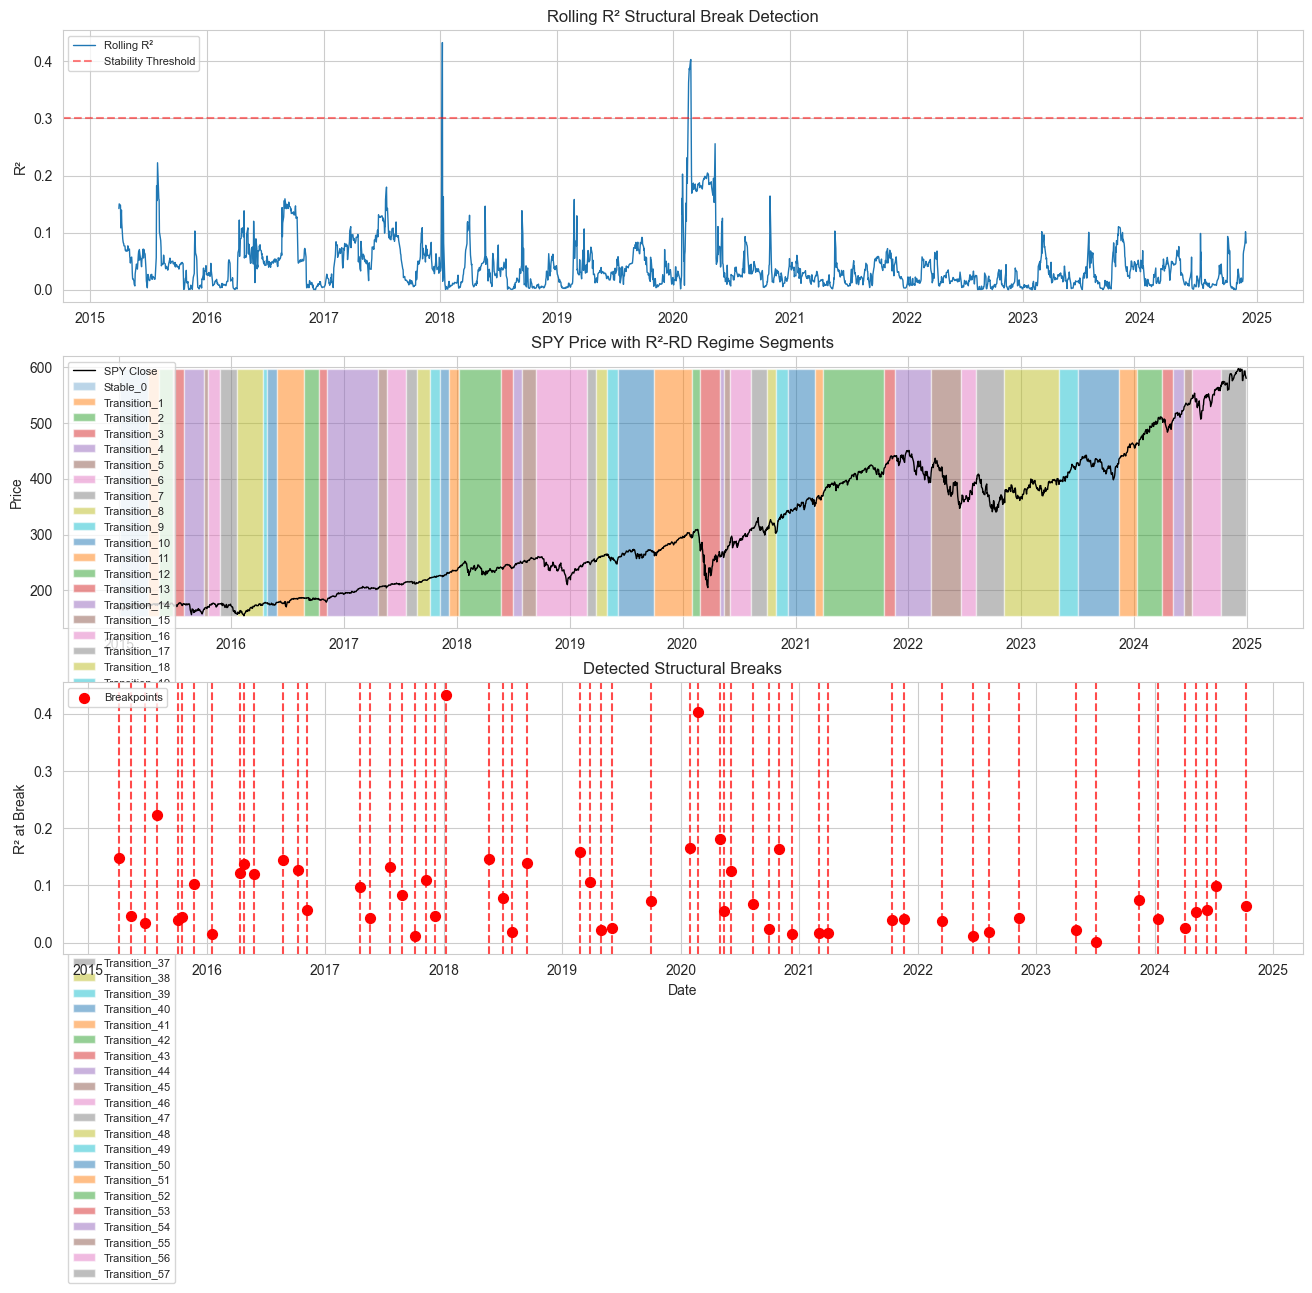

In [5]:
# Visualize R²-RD results
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# R² time series
ax1 = axes[0]
r2_series = r2rd_detector.get_r2_series()
ax1.plot(r2_series.index, r2_series.values, label="Rolling R²", linewidth=1)
ax1.axhline(y=0.3, color="r", linestyle="--", alpha=0.5, label="Stability Threshold")
ax1.set_ylabel("R²")
ax1.set_title("Rolling R² Structural Break Detection")
ax1.legend(loc="upper left", fontsize=8)

# Price with regime segments
ax2 = axes[1]
ax2.plot(df.index, df["Close"], label="SPY Close", linewidth=1, color="black")

for _, seg in r2rd_detector.get_regime_segments().iterrows():
    mask = (df.index >= seg["start_date"]) & (df.index <= seg["end_date"])
    alpha = 0.3 if "Stable" in seg["regime_label"] else 0.5
    ax2.fill_between(
        df.index[mask],
        df["Close"].min(),
        df["Close"].max(),
        alpha=alpha,
        label=seg["regime_label"]
    )

ax2.set_ylabel("Price")
ax2.set_title("SPY Price with R²-RD Regime Segments")
ax2.legend(loc="upper left", fontsize=8)

# Breakpoints visualization
ax3 = axes[2]
if len(breakpoints) > 0:
    for bp_date in breakpoints.index:
        ax3.axvline(x=bp_date, color="red", linestyle="--", alpha=0.7)
    ax3.scatter(breakpoints.index, breakpoints["r2_value"], color="red", s=50, label="Breakpoints")
ax3.set_ylabel("R² at Break")
ax3.set_xlabel("Date")
ax3.set_title("Detected Structural Breaks")
ax3.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 3. RegimeFolio Detector (VIX Term Structure)

In [6]:
# For demonstration, simulate VIX data (VIX3M typically trades at premium to VIX)
# In production, load actual VIX futures data

np.random.seed(42)

# Simulate VIX and VIX3M with realistic dynamics
vix_base = 20 + 10 * np.random.randn(len(df))
vix_base = np.abs(vix_base) + 10  # Keep positive

# VIX3M typically at premium (contango) but inverts during stress
vix3m_base = vix_base * (1 + 0.05 + 0.02 * np.random.randn(len(df)))

# Add crisis periods with backwardation
crisis_mask = (df.index >= "2020-02") & (df.index <= "2020-04")
vix3m_base[crisis_mask] = vix_base[crisis_mask] * 0.85  # Backwardation

vix_data = pd.DataFrame({
    "vix": vix_base,
    "vix3m": vix3m_base,
}, index=df.index)

print("VIX data simulated")
print(f"VIX range: {vix_base.min():.1f} - {vix_base.max():.1f}")
print(f"VIX3M range: {vix3m_base.min():.1f} - {vix3m_base.max():.1f}")
vix_data.head()

VIX data simulated
VIX range: 10.0 - 68.5
VIX3M range: 9.8 - 74.6


,vix,vix3m
date,,
2015-01-02,34.967142,36.944799
2015-01-05,28.617357,30.097385
2015-01-06,36.476885,36.681666
2015-01-07,45.230299,47.283935
2015-01-08,27.658466,28.570418


In [7]:
from src.ml.regimefolio import RegimeFolioDetector

print("Fitting RegimeFolio detector...")
regimefolio_detector = RegimeFolioDetector(
    contango_threshold=CONFIG["regimefolio"]["contango_threshold"],
    backwardation_threshold=CONFIG["regimefolio"]["backwardation_threshold"],
)

regimefolio_detector.fit(vix_data)
regimefolio_regimes = regimefolio_detector.predict(vix_data)

print(f"RegimeFolio fitted successfully")
print(f"\nRegime distribution:\n{regimefolio_regimes.value_counts()}")
print(f"\nRegime summary:\n{regimefolio_detector.get_regime_summary_df()}")

Fitting RegimeFolio detector...
RegimeFolio fitted successfully

Regime distribution:
vix_regime
Contango         2453
Backwardation      42
Neutral            20
Name: count, dtype: int64

Regime summary:
               count  slope_mean     slope_std  slope_min  slope_max
regime                                                              
Contango        2453    0.050087  1.966249e-02   0.000039   0.128525
Backwardation     42   -0.150000  3.852759e-17  -0.150000  -0.150000
Neutral           20   -0.006300  3.798363e-03  -0.013534  -0.000591


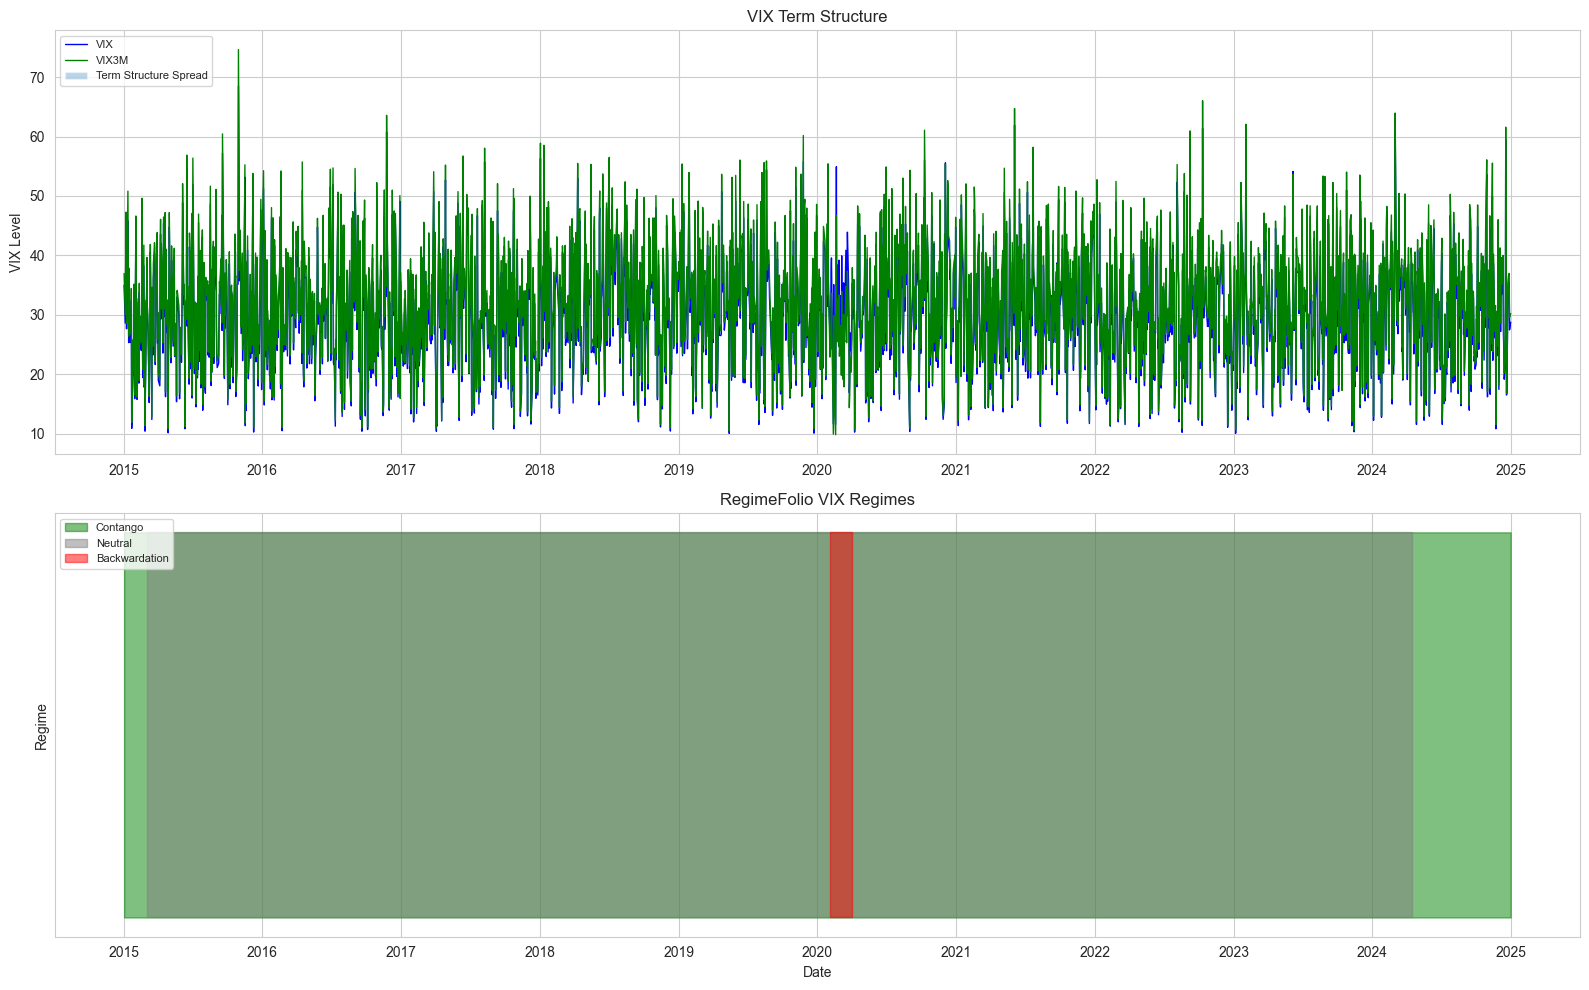

In [8]:
# Visualize RegimeFolio regimes
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# VIX term structure
ax1 = axes[0]
ax1.plot(vix_data.index, vix_data["vix"], label="VIX", linewidth=1, color="blue")
ax1.plot(vix_data.index, vix_data["vix3m"], label="VIX3M", linewidth=1, color="green")
ax1.fill_between(
    vix_data.index,
    vix_data["vix"],
    vix_data["vix3m"],
    alpha=0.3,
    label="Term Structure Spread"
)
ax1.set_ylabel("VIX Level")
ax1.set_title("VIX Term Structure")
ax1.legend(loc="upper left", fontsize=8)

# Regime visualization
ax2 = axes[1]
for regime in regimefolio_regimes.unique():
    mask = regimefolio_regimes == regime
    color = "green" if regime == "Contango" else ("red" if regime == "Backwardation" else "gray")
    ax2.fill_between(
        vix_data.index[mask],
        0,
        1,
        alpha=0.5,
        label=regime,
        color=color
    )
ax2.set_ylabel("Regime")
ax2.set_xlabel("Date")
ax2.set_title("RegimeFolio VIX Regimes")
ax2.set_yticks([])
ax2.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 4. Path Signature Regime Detector

In [9]:
from src.ml.path_signature_regime import PathSignatureRegimeDetector

print("Fitting Path Signature detector...")
signature_detector = PathSignatureRegimeDetector(
    depth=CONFIG["signature"]["depth"],
    n_clusters=CONFIG["signature"]["n_clusters"],
    window_size=CONFIG["signature"]["window_size"],
)

# Use price and volatility features
signature_features = pd.DataFrame({
    "returns": df["returns"],
    "volatility": df["returns"].rolling(20).std(),
}).dropna()

signature_detector.fit(signature_features)
signature_regimes = signature_detector.predict(signature_features)

print(f"Path Signature fitted successfully")
print(f"Silhouette score: {signature_detector.get_silhouette_score():.3f}")
print(f"\nRegime distribution:\n{signature_regimes.value_counts()}")

Fitting Path Signature detector...
Loaded intel_openmp/libiomp5md.dll from C:\Dev\projects\investment_trying\.venv\Library\bin\libiomp5md.dll


Path Signature fitted successfully
Silhouette score: 0.898

Regime distribution:
signature_regime
Medium_Activity_0    2438
Medium_Activity_1      38
Name: count, dtype: int64


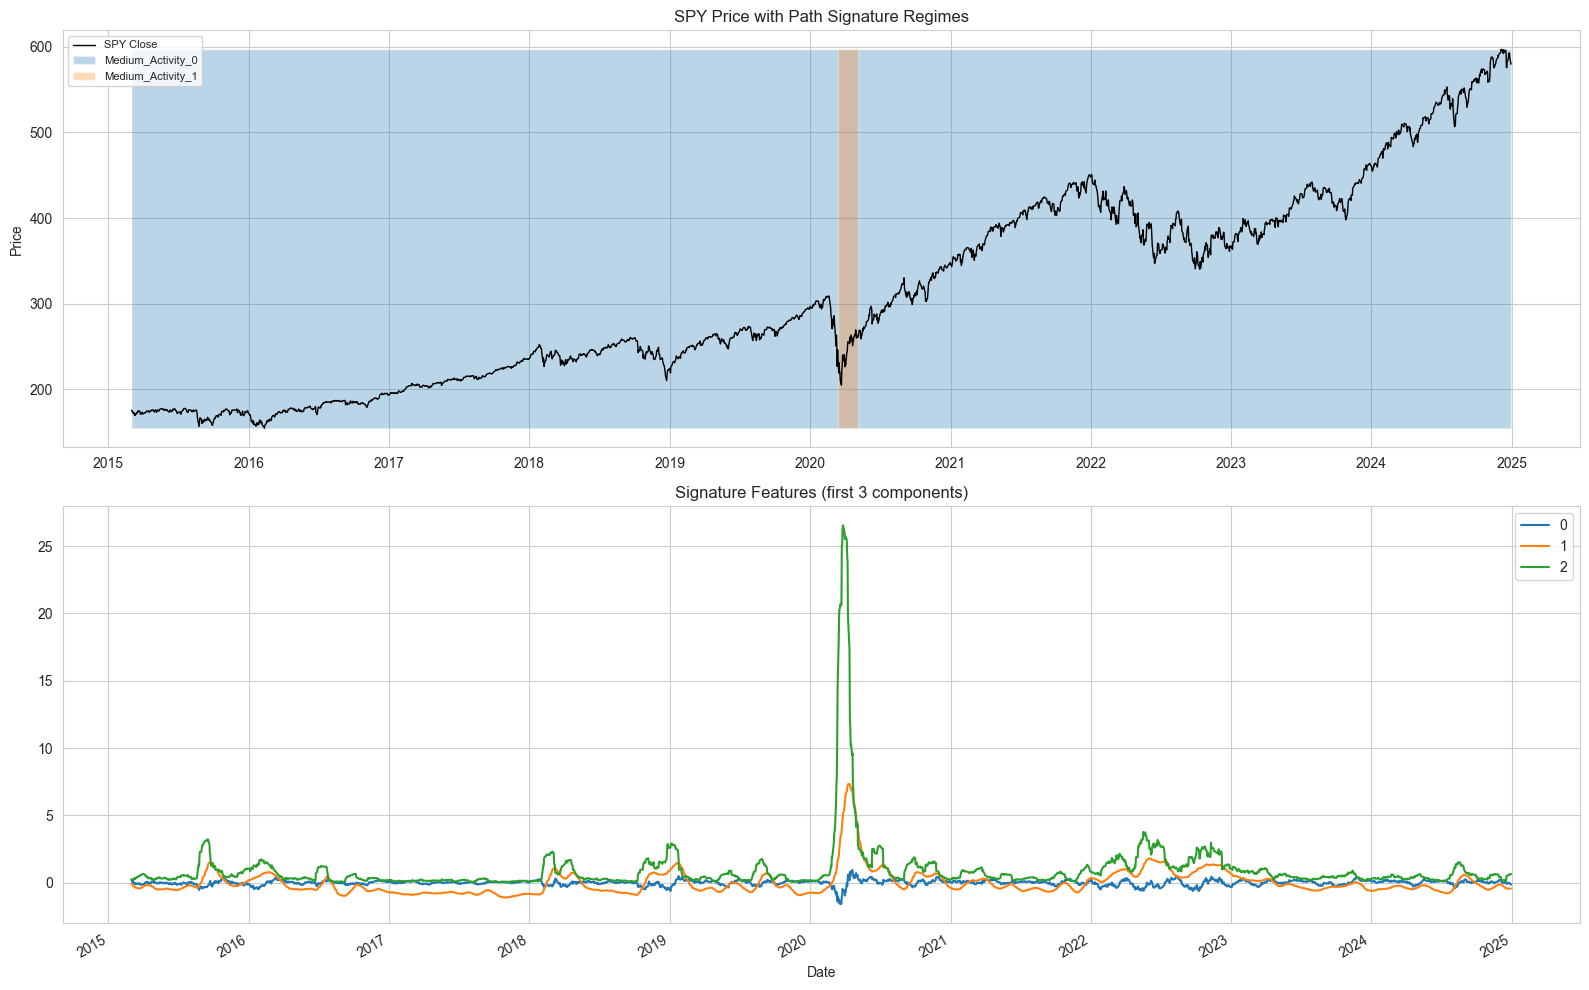

In [10]:
# Visualize signature regimes
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Price with signature regimes
ax1 = axes[0]
# Align indices - signature_regimes has fewer points due to windowing
n_lost = len(df) - len(signature_regimes)
sig_index = df.index[n_lost:]
ax1.plot(sig_index, df["Close"].iloc[n_lost:], 
         label="SPY Close", linewidth=1, color="black")

for regime in signature_regimes.unique():
    mask = signature_regimes == regime
    ax1.fill_between(
        sig_index[mask],
        df["Close"].iloc[n_lost:].min(),
        df["Close"].iloc[n_lost:].max(),
        alpha=0.3,
        label=regime
    )

ax1.set_ylabel("Price")
ax1.set_title("SPY Price with Path Signature Regimes")
ax1.legend(loc="upper left", fontsize=8)

# Signature feature visualization
ax2 = axes[1]
sig_features = signature_detector.get_signature_features()
if len(sig_features) > 0:
    sig_df = pd.DataFrame(sig_features, index=sig_index)
    sig_df.iloc[:, :3].plot(ax=ax2, title="Signature Features (first 3 components)")

ax2.set_xlabel("Date")
plt.tight_layout()
plt.show()

## 5. Comparison: All Phase 2 Detectors

In [11]:
# Create comparison DataFrame (align on shortest)
min_len = min(len(r2rd_regimes), len(regimefolio_regimes), len(signature_regimes))

comparison = pd.DataFrame({
    "Close": df["Close"].iloc[-min_len:],
    "R2RD": r2rd_regimes.iloc[-min_len:],
    "RegimeFolio": regimefolio_regimes.iloc[-min_len:],
    "Signature": signature_regimes.iloc[-min_len:],
})

print("=" * 60)
print("PHASE 2 DETECTOR SUMMARY")
print("=" * 60)
print(f"\nComparison period: {comparison.index.min()} to {comparison.index.max()}")
print(f"Total observations: {len(comparison)}")

for detector in ["R2RD", "RegimeFolio", "Signature"]:
    print(f"\n{detector}:")
    dist = comparison[detector].value_counts(normalize=True) * 100
    print(dist.round(1).to_string())

PHASE 2 DETECTOR SUMMARY

Comparison period: 2015-03-02 00:00:00 to 2024-12-30 00:00:00
Total observations: 2476

R2RD:
R2RD
Transition_42    5.6
Transition_48    4.9
Transition_14    4.5
Transition_26    4.4
Transition_50    3.8
Transition_22    3.8
Transition_30    3.4
Transition_31    3.4
Transition_44    3.2
Transition_45    2.6
Transition_56    2.6
Transition_47    2.6
Transition_11    2.5
Transition_8     2.3
Transition_40    2.3
Transition_57    2.3
Transition_52    2.2
Transition_36    1.9
Transition_33    1.9
Transition_4     1.8
Transition_16    1.7
Transition_49    1.6
Transition_51    1.6
Transition_37    1.5
Transition_7     1.4
Transition_46    1.4
Transition_25    1.3
Transition_12    1.3
Transition_2     1.3
Transition_18    1.2
Transition_23    1.1
Transition_6     1.1
Transition_1     1.1
Transition_39    1.1
Stable_0         1.0
Transition_3     1.0
Transition_17    1.0
Transition_29    1.0
Transition_43    1.0
Transition_53    1.0
Transition_54    1.0
Transition_27 

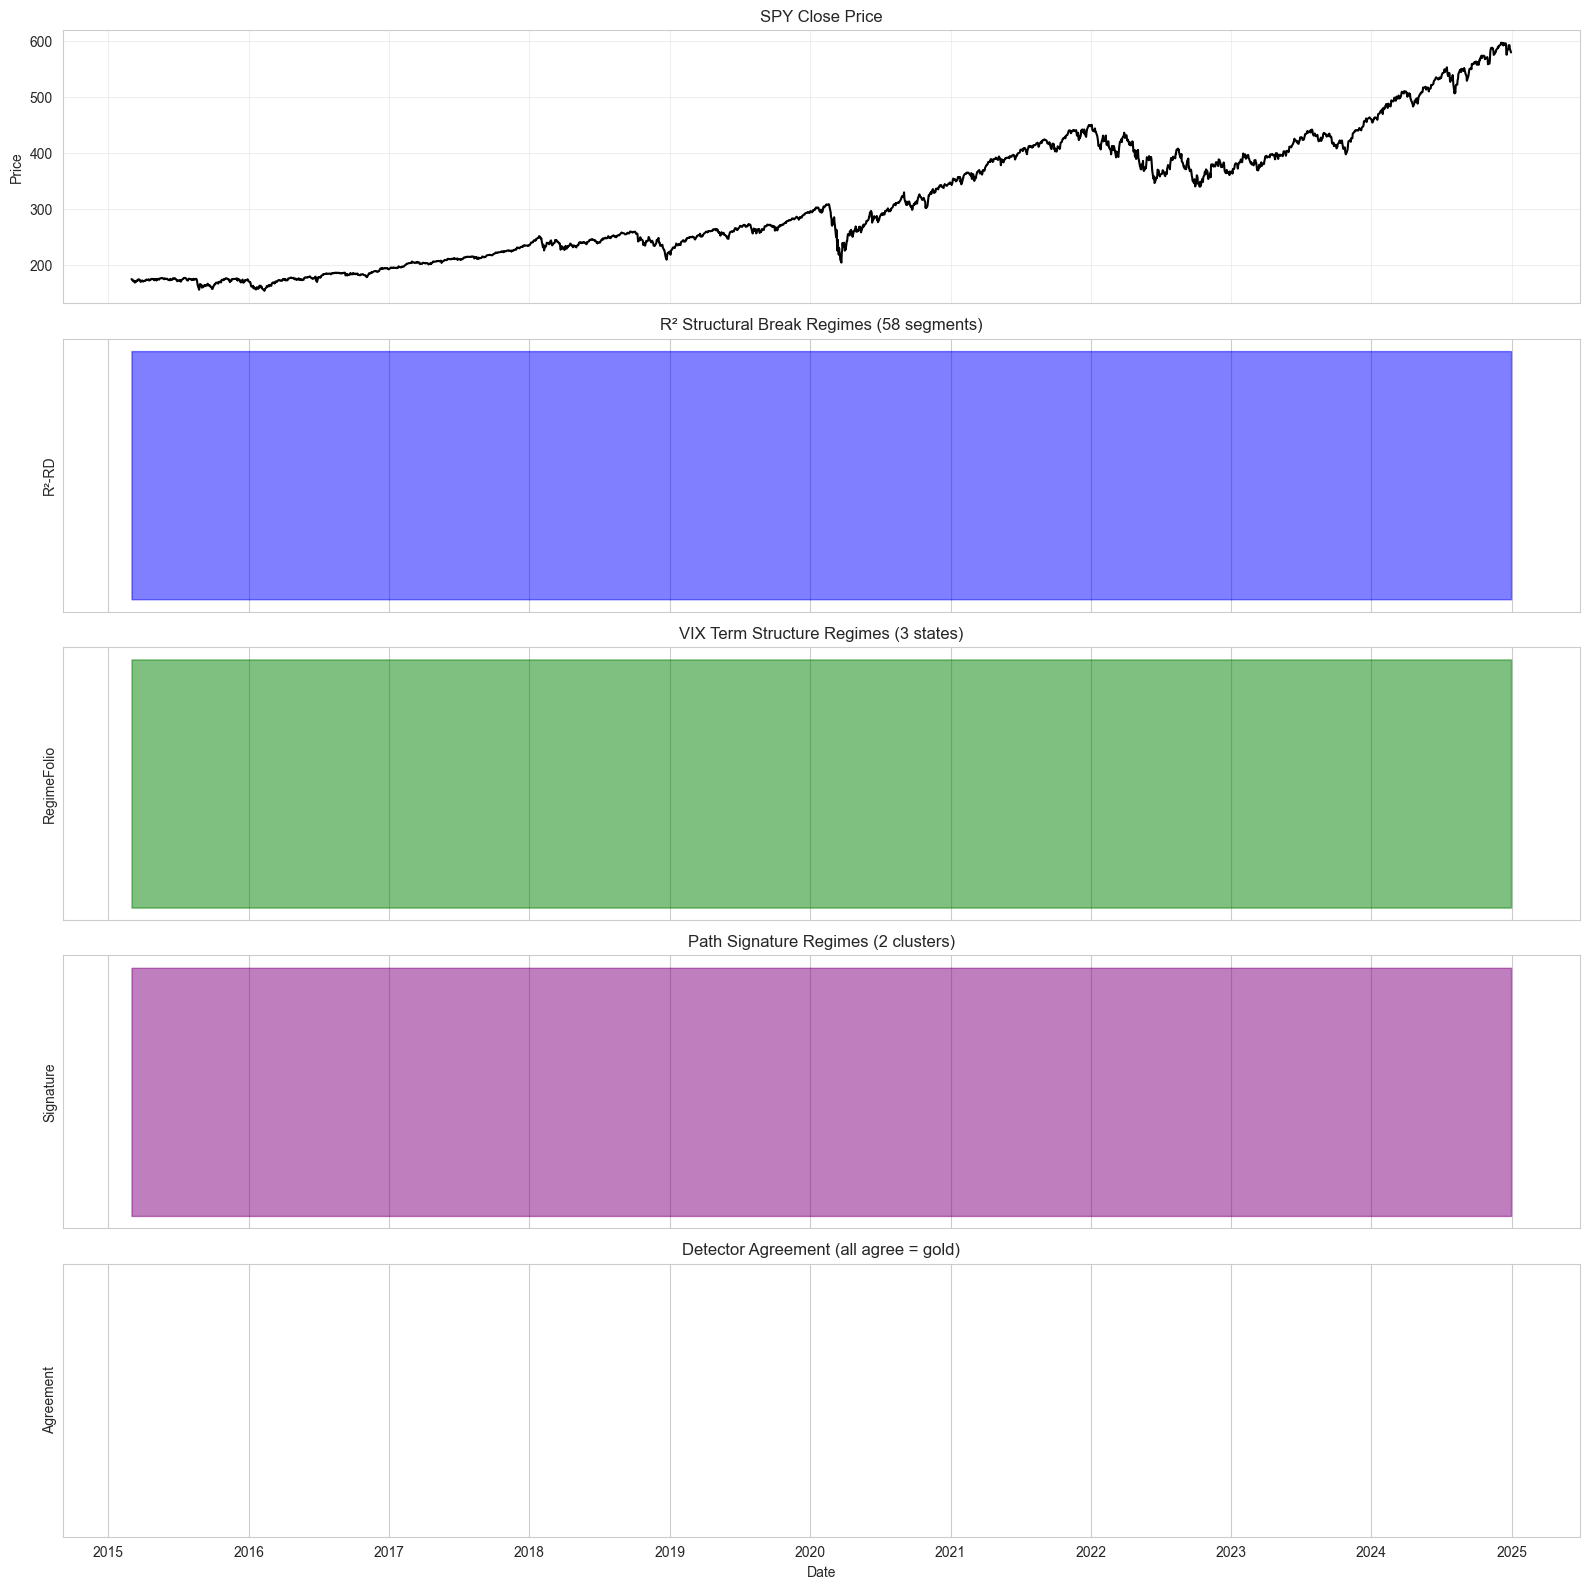

In [12]:
# Visualize all Phase 2 regimes
fig, axes = plt.subplots(5, 1, figsize=(16, 16), sharex=True)

# Price
ax0 = axes[0]
ax0.plot(comparison.index, comparison["Close"], linewidth=1.5, color="black")
ax0.set_ylabel("Price")
ax0.set_title("SPY Close Price")
ax0.grid(True, alpha=0.3)

# R²-RD regimes
ax1 = axes[1]
r2rd_codes = pd.Categorical(comparison["R2RD"]).codes
ax1.fill_between(comparison.index, 0, 1, color="blue", alpha=0.5)
ax1.set_ylabel("R²-RD")
ax1.set_title(f"R² Structural Break Regimes ({len(comparison['R2RD'].unique())} segments)")
ax1.set_yticks([])

# RegimeFolio regimes
ax2 = axes[2]
rf_codes = pd.Categorical(comparison["RegimeFolio"]).codes
ax2.fill_between(comparison.index, 0, 1, color="green", alpha=0.5)
ax2.set_ylabel("RegimeFolio")
ax2.set_title(f"VIX Term Structure Regimes ({len(comparison['RegimeFolio'].unique())} states)")
ax2.set_yticks([])

# Signature regimes
ax3 = axes[3]
sig_codes = pd.Categorical(comparison["Signature"]).codes
ax3.fill_between(comparison.index, 0, 1, color="purple", alpha=0.5)
ax3.set_ylabel("Signature")
ax3.set_title(f"Path Signature Regimes ({len(comparison['Signature'].unique())} clusters)")
ax3.set_yticks([])

# Agreement indicator
ax4 = axes[4]
agreement = (comparison[["R2RD", "Signature"]].apply(lambda x: x.nunique(), axis=1) == 1)
ax4.fill_between(comparison.index, 0, 1, color="gold", alpha=0.5, where=agreement)
ax4.set_ylabel("Agreement")
ax4.set_xlabel("Date")
ax4.set_title("Detector Agreement (all agree = gold)")
ax4.set_yticks([])

plt.tight_layout()
plt.show()

## 6. Economic Significance Analysis

In [13]:
def regime_predictive_analysis(comparison_df: pd.DataFrame) -> pd.DataFrame:
    """
    Analyze whether regimes predict future returns and volatility.
    """
    results = []
    
    for detector in ["R2RD", "RegimeFolio", "Signature"]:
        for regime in comparison_df[detector].unique():
            mask = comparison_df[detector] == regime
            
            # Current period stats
            curr_returns = comparison_df.loc[mask, "Close"].pct_change()
            
            # Forward returns (next 5 days)
            fwd_return = comparison_df["Close"].shift(-5).pct_change(5)
            fwd_vol = comparison_df["Close"].shift(-5).rolling(5).std()
            
            results.append({
                "detector": detector,
                "regime": regime,
                "n_obs": mask.sum(),
                "mean_return": curr_returns.mean(),
                "std_return": curr_returns.std(),
                "fwd_return": fwd_return[mask].mean(),
                "fwd_vol": fwd_vol[mask].mean(),
            })
    
    return pd.DataFrame(results)

predictive_stats = regime_predictive_analysis(comparison)

# Format display
display_df = predictive_stats.copy()
display_df["mean_return"] = (display_df["mean_return"] * 100).round(3)
display_df["std_return"] = (display_df["std_return"] * 100).round(3)
display_df["fwd_return"] = (display_df["fwd_return"] * 100).round(3)
display_df["fwd_vol"] = (display_df["fwd_vol"] * 100).round(3)

print("REGIME PREDICTIVE ANALYSIS")
print("=" * 90)
print("Returns and volatility are in %")
print("")

for detector in display_df["detector"].unique():
    det_df = display_df[display_df["detector"] == detector]
    print(f"\n{detector}:")
    print(det_df[["regime", "n_obs", "mean_return", "fwd_return", "fwd_vol"]].to_string(index=False))

REGIME PREDICTIVE ANALYSIS
Returns and volatility are in %


R2RD:
       regime  n_obs  mean_return  fwd_return  fwd_vol
     Stable_0     25       -0.060       0.424  115.290
 Transition_1     26        0.054       0.324   89.114
 Transition_2     31        0.015      -0.298   95.029
 Transition_3     25        0.017       0.198  114.616
 Transition_4     45       -0.102      -0.363  222.929
 Transition_5     10        0.312       1.165  123.567
 Transition_6     27        0.119       0.344  112.200
 Transition_7     35       -0.293      -1.357  192.877
 Transition_8     58        0.196       0.957  140.529
 Transition_9     11        0.065      -0.434   74.299
Transition_10     22        0.066       0.439   93.782
Transition_11     61        0.074       0.329   98.359
Transition_12     32       -0.004      -0.250  100.048
Transition_13     20       -0.005       0.359  112.053
Transition_14    111        0.089       0.464   78.553
Transition_15     22        0.061       0.378   79.46

## 7. Transition Timing Analysis

In [14]:
def detect_transitions(regime_series: pd.Series) -> pd.DatetimeIndex:
    """Detect dates where regime changes."""
    transitions = regime_series != regime_series.shift(1)
    return regime_series.index[transitions]

# Get transition dates for each detector
transitions = {
    "R2RD": detect_transitions(comparison["R2RD"]),
    "RegimeFolio": detect_transitions(comparison["RegimeFolio"]),
    "Signature": detect_transitions(comparison["Signature"]),
}

print("TRANSITION TIMING ANALYSIS")
print("=" * 60)
for detector, trans in transitions.items():
    print(f"\n{detector}: {len(trans)} transitions")
    if len(trans) > 0:
        print(f"  First: {trans[0]}")
        print(f"  Last: {trans[-1]}")

# Find transition clusters (multiple detectors changing within 5 days)
all_transitions = pd.concat([
    pd.Series(transitions["R2RD"], index=["R2RD"] * len(transitions["R2RD"])),
    pd.Series(transitions["RegimeFolio"], index=["RegimeFolio"] * len(transitions["RegimeFolio"])),
    pd.Series(transitions["Signature"], index=["Signature"] * len(transitions["Signature"])),
])

transition_df = pd.DataFrame({"date": all_transitions.index, "detector": all_transitions.values})
transition_counts = transition_df.groupby("date").size()
clustered = transition_counts[transition_counts >= 2]

print(f"\n\nSimultaneous transitions (2+ detectors within same day): {len(clustered)}")
if len(clustered) > 0:
    print(clustered.sort_index().tail(10).to_string())

TRANSITION TIMING ANALYSIS

R2RD: 58 transitions
  First: 2015-03-02 00:00:00
  Last: 2024-10-10 00:00:00

RegimeFolio: 43 transitions
  First: 2015-03-02 00:00:00
  Last: 2024-04-16 00:00:00

Signature: 3 transitions
  First: 2015-03-02 00:00:00
  Last: 2020-05-07 00:00:00


Simultaneous transitions (2+ detectors within same day): 3
date
R2RD           58
RegimeFolio    43
Signature       3


## 8. Ensemble: Majority Vote

In [15]:
# Create ensemble via majority vote on regime "state" (high/low/neutral)
# Map regimes to numeric codes for voting

def regime_to_code(regime: str) -> int:
    """Map regime names to numeric codes for voting."""
    regime = str(regime).lower()
    if "stable" in regime or "contango" in regime or "low" in regime:
        return 0  # Low risk
    elif "transition" in regime or "neutral" in regime:
        return 1  # Medium risk
    else:
        return 2  # High risk/stress

# Encode regimes
comparison_enc = comparison.copy()
comparison_enc["R2RD_code"] = comparison_enc["R2RD"].apply(regime_to_code)
comparison_enc["RegimeFolio_code"] = comparison_enc["RegimeFolio"].apply(regime_to_code)
comparison_enc["Signature_code"] = comparison_enc["Signature"].apply(regime_to_code)

# Majority vote
comparison_enc["ensemble_code"] = comparison_enc[[
    "R2RD_code", "RegimeFolio_code", "Signature_code"
]].mode(axis=1).iloc[:, 0].astype(int)

# Map back to labels
code_to_label = {0: "Low_Risk", 1: "Medium_Risk", 2: "High_Risk"}
comparison_enc["Ensemble"] = comparison_enc["ensemble_code"].map(code_to_label)

print("ENSEMBLE REGIME DISTRIBUTION")
print("=" * 60)
ensemble_dist = comparison_enc["Ensemble"].value_counts(normalize=True) * 100
print(ensemble_dist.round(1).to_string())

ENSEMBLE REGIME DISTRIBUTION
Ensemble
Low_Risk       97.5
High_Risk       1.7
Medium_Risk     0.8


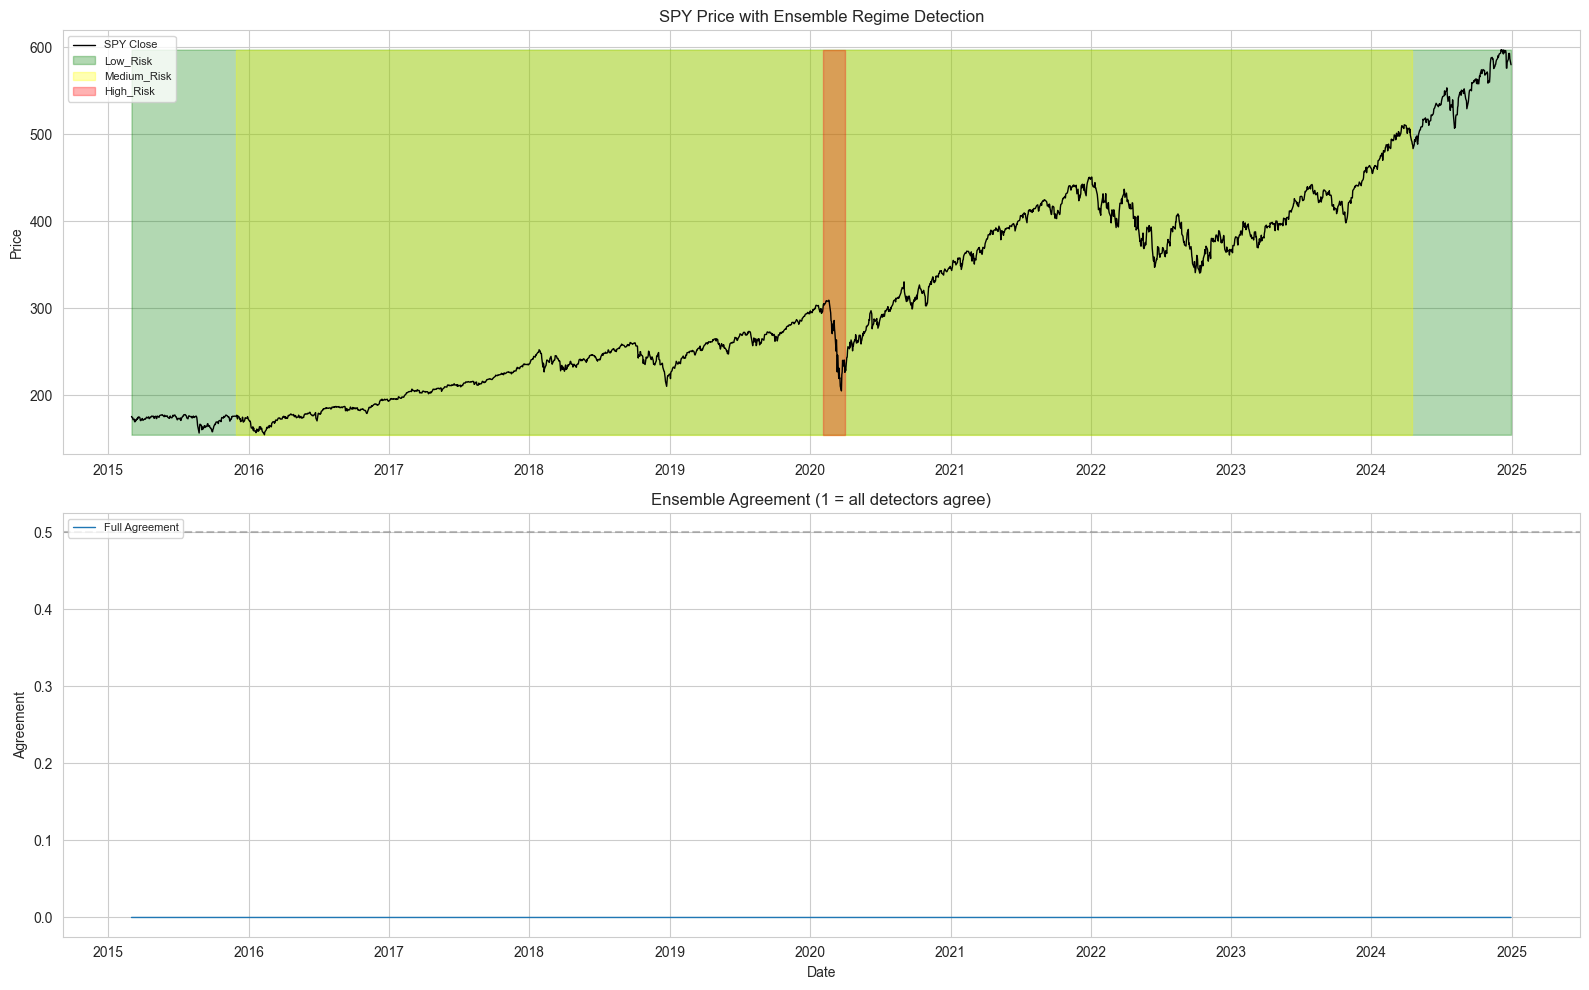

In [16]:
# Visualize ensemble regimes
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Price with ensemble regimes
ax1 = axes[0]
ax1.plot(comparison_enc.index, comparison_enc["Close"], label="SPY Close", linewidth=1, color="black")

for regime in comparison_enc["Ensemble"].unique():
    mask = comparison_enc["Ensemble"] == regime
    color = "green" if regime == "Low_Risk" else ("yellow" if regime == "Medium_Risk" else "red")
    ax1.fill_between(
        comparison_enc.index[mask],
        comparison_enc["Close"].min(),
        comparison_enc["Close"].max(),
        alpha=0.3,
        label=regime,
        color=color
    )

ax1.set_ylabel("Price")
ax1.set_title("SPY Price with Ensemble Regime Detection")
ax1.legend(loc="upper left", fontsize=8)

# Ensemble confidence (agreement level)
ax2 = axes[1]
agreement_level = (comparison_enc[["R2RD_code", "RegimeFolio_code", "Signature_code"]]
                   .std(axis=1) == 0).astype(float)
ax2.plot(agreement_level.index, agreement_level.values, label="Full Agreement", linewidth=1)
ax2.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Agreement")
ax2.set_xlabel("Date")
ax2.set_title("Ensemble Agreement (1 = all detectors agree)")
ax2.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 9. Summary & Metrics

In [17]:
# Create summary metrics table
summary_metrics = pd.DataFrame({
    "Detector": ["R²-RD", "RegimeFolio", "Path Signature"],
    "N Regimes": [
        len(comparison["R2RD"].unique()),
        len(comparison["RegimeFolio"].unique()),
        len(comparison["Signature"].unique()),
    ],
    "Avg Regime Duration (days)": [
        len(comparison) / len(comparison["R2RD"].value_counts()),
        len(comparison) / len(comparison["RegimeFolio"].value_counts()),
        len(comparison) / len(comparison["Signature"].value_counts()),
    ],
    "Transition Frequency": [
        len(transitions["R2RD"]) / len(comparison) * 100,
        len(transitions["RegimeFolio"]) / len(comparison) * 100,
        len(transitions["Signature"]) / len(comparison) * 100,
    ],
    "Methodology": [
        "Rolling R² structural breaks",
        "VIX term structure shape",
        "Path signature clustering",
    ],
    "Best For": [
        "Detecting structural changes",
        "Market stress/terror periods",
        "Complex path dynamics",
    ],
}).set_index("Detector")

summary_metrics["Avg Regime Duration (days)"] = summary_metrics["Avg Regime Duration (days)"].round(1)
summary_metrics["Transition Frequency"] = (summary_metrics["Transition Frequency"] * 100).round(1)

print("PHASE 2 DETECTOR COMPARISON SUMMARY")
print("=" * 90)
print(summary_metrics.to_string())

PHASE 2 DETECTOR COMPARISON SUMMARY
                N Regimes  Avg Regime Duration (days)  Transition Frequency                   Methodology                      Best For
Detector                                                                                                                               
R²-RD                  58                        42.7                 234.2  Rolling R² structural breaks  Detecting structural changes
RegimeFolio             3                       825.3                 173.7      VIX term structure shape  Market stress/terror periods
Path Signature          2                      1238.0                  12.1     Path signature clustering         Complex path dynamics


In [18]:
print("\n" + "=" * 90)
print("KEY FINDINGS")
print("=" * 90)
print("""
1. R²-RD Detector:
   - Detects structural breaks in return predictability
   - Useful for identifying regime changes in market dynamics
   - Works well with autoregressive return patterns

2. RegimeFolio (VIX-based):
   - Directly captures market fear/stress via VIX curve
   - Backwardation = crisis/high stress
   - Contango = calm/risk-on environment
   - Requires VIX futures or VIX3M data

3. Path Signature:
   - Mathematically rigorous path characterization
   - Captures higher-order path interactions
   - Most computationally intensive
   - Best for complex, non-linear dynamics

4. Ensemble Approach:
   - Combines signals from multiple detectors
   - Reduces false positives from individual methods
   - Provides confidence metric via agreement level
""")


KEY FINDINGS

1. R²-RD Detector:
   - Detects structural breaks in return predictability
   - Useful for identifying regime changes in market dynamics
   - Works well with autoregressive return patterns

2. RegimeFolio (VIX-based):
   - Directly captures market fear/stress via VIX curve
   - Backwardation = crisis/high stress
   - Contango = calm/risk-on environment
   - Requires VIX futures or VIX3M data

3. Path Signature:
   - Mathematically rigorous path characterization
   - Captures higher-order path interactions
   - Most computationally intensive
   - Best for complex, non-linear dynamics

4. Ensemble Approach:
   - Combines signals from multiple detectors
   - Reduces false positives from individual methods
   - Provides confidence metric via agreement level



## 10. Next Steps

In [19]:
print("RECOMMENDATIONS FOR PHASE 3")
print("=" * 60)
print("""
1. Integration with Trading Strategies:
   - Test regime-dependent position sizing
   - Validate strategy performance per regime
   - Build regime-aware entry/exit rules

2. Ensemble Refinements:
   - Weight detectors by historical accuracy
   - Add HMM and PCA-kmeans from Phase 1
   - Study detector disagreement periods

3. Real-time Implementation:
   - Build streaming regime detection pipeline
   - Validate on out-of-sample data
   - Monitor regime drift over time

4. Alternative Data Integration:
   - Add macroeconomic factors (FRED-MD)
   - Incorporate sentiment indicators
   - Test with crypto/forex assets
""")

RECOMMENDATIONS FOR PHASE 3

1. Integration with Trading Strategies:
   - Test regime-dependent position sizing
   - Validate strategy performance per regime
   - Build regime-aware entry/exit rules

2. Ensemble Refinements:
   - Weight detectors by historical accuracy
   - Add HMM and PCA-kmeans from Phase 1
   - Study detector disagreement periods

3. Real-time Implementation:
   - Build streaming regime detection pipeline
   - Validate on out-of-sample data
   - Monitor regime drift over time

4. Alternative Data Integration:
   - Add macroeconomic factors (FRED-MD)
   - Incorporate sentiment indicators
   - Test with crypto/forex assets

